In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

DATA_PATH = r"C:\OFFICE\GOLDSTONE\cementAI\Data\cement_mill_2023_2024_2025_merged.csv"   
CONFIG_PATH = "config.yaml"          

# load data

In [2]:

df = pd.read_csv(DATA_PATH)
df

,Datetime,total_feed(TPH),reject(TPH),sep_drive_speed(RPM),bucket_elevator(AMP),mill_sound(%),cement_category
0,01-04-2023 00:00,118.486454,8.024420,570.733521,53.821735,78.437119,0.0
1,01-04-2023 01:00,119.675951,14.042735,570.733521,58.315022,81.343102,0.0
2,01-04-2023 02:00,119.404398,16.890110,570.733521,58.119659,83.418808,0.0
3,01-04-2023 03:00,118.955072,8.024420,570.733521,58.998783,84.053726,0.0
4,01-04-2023 04:00,119.241518,13.978023,570.733521,58.608063,82.881561,0.0
...,...,...,...,...,...,...,...
22833,30-01-2026 19:00,110.864469,264.094025,808.479981,62.222225,89.841270,1.0
22834,30-01-2026 20:00,99.130651,243.126984,801.372498,66.178268,90.305252,0.0
22835,30-01-2026 21:00,104.230777,79.661789,834.067078,52.356537,89.719170,0.0
22836,30-01-2026 22:00,104.261301,215.429794,900.166992,55.286938,84.737488,0.0


In [3]:
df.isnull().sum()

Datetime                  0
total_feed(TPH)           0
reject(TPH)              57
sep_drive_speed(RPM)     57
bucket_elevator(AMP)     57
mill_sound(%)            57
cement_category         504
dtype: int64

In [4]:
print("column names are:" ,df.columns.to_list())

column names are: ['Datetime', 'total_feed(TPH)', 'reject(TPH)', 'sep_drive_speed(RPM)', 'bucket_elevator(AMP)', 'mill_sound(%)', 'cement_category']


# Cleaning and Standardization

In [8]:
def clean_cement_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # convert timestamp
    df["Datetime"] = pd.to_datetime(df["Datetime"], dayfirst=True)

    # numeric conversion
    numeric_cols = [
        "total_feed(TPH)",
        "reject(TPH)",
        "sep_drive_speed(RPM)",
        "bucket_elevator(AMP)",
        "mill_sound(%)",
        "cement_category"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # remove rows with missing critical values
    required_cols = [
        "Datetime",
        "total_feed(TPH)",
        "sep_drive_speed(RPM)",
        "bucket_elevator(AMP)",
        "mill_sound(%)",
        "cement_category"
    ]
    df = df.dropna(subset=required_cols)

    # remove zero values (invalid sensor readings)
    for col in [
        "total_feed(TPH)",
        "sep_drive_speed(RPM)",
        "bucket_elevator(AMP)",
        "mill_sound(%)"
    ]:
        df = df[df[col] > 0]

    # remove low feed region (below operating range)
    df = df[df["total_feed(TPH)"] >= 100]

    # convert category to int
    df["cement_category"] = df["cement_category"].astype(int)

    # sort
    df = df.sort_values("Datetime").reset_index(drop=True)

    return df

df_clean = clean_cement_data(df)

print("Final shape:", df_clean.shape)
print("Original shape:", df.shape)

print("\nCategory counts:")
print(df_clean["cement_category"].value_counts().sort_index())

print("\nBasic stats:")
df_clean[[
    "total_feed(TPH)",
    "mill_sound(%)",
    "bucket_elevator(AMP)",
    "sep_drive_speed(RPM)",
    "reject(TPH)"]].describe()



Final shape: (16427, 7)
Original shape: (22838, 7)

Category counts:
cement_category
0    12444
1     3983
Name: count, dtype: int64

Basic stats:


,total_feed(TPH),mill_sound(%),bucket_elevator(AMP),sep_drive_speed(RPM),reject(TPH)
count,16427.000000,16427.000000,16427.000000,16427.000000,16427.000000
mean,115.971935,73.234617,55.221858,628.546826,76.341665
std,8.570524,10.060063,6.887644,213.104088,89.741180
min,100.004642,24.615385,40.586082,76.050423,0.000000
25%,109.646283,66.007324,50.500614,504.278320,4.012210
50%,115.265448,73.846153,53.821735,679.478577,34.880344
75%,121.242248,80.512825,58.266182,776.140808,124.702080
max,151.288400,96.703300,83.711845,1081.408691,264.546997


In [7]:
print("\nStats by Cement Category:")

grouped_stats = df_clean.groupby("cement_category")[[
    "total_feed(TPH)",
    "mill_sound(%)",
    "bucket_elevator(AMP)",
    "sep_drive_speed(RPM)"
]].describe()

grouped_stats.T


Stats by Cement Category:


cement_category                        0            1
total_feed(TPH)      count  12444.000000  3983.000000
                     mean     117.018898   112.700934
                     std        8.711721     7.191634
                     min      100.004642   100.012214
                     25%      110.518200   107.484863
                     50%      116.499637   111.838829
                     75%      122.470148   117.231015
                     max      151.288400   145.301833
mill_sound(%)        count  12444.000000  3983.000000
                     mean      73.781133    71.527148
                     std        9.889043    10.394305
                     min       29.963371    24.615385
                     25%       66.904762    64.139194
                     50%       75.067154    70.695969
                     75%       80.805862    78.510376
                     max       96.605614    96.703300
bucket_elevator(AMP) count  12444.000000  3983.000000
                     mean      53.460436    60.725031
                     std        5.268425     8.304813
                     min       40.586082    41.562881
                     25%       49.816849    54.407818
                     50%       52.820517    59.829063
                     75%       56.019539    66.568985
                     max       83.076927    83.711845
sep_drive_speed(RPM) count  12444.000000  3983.000000
                     mean     613.141534   676.677242
                     std      229.265227   141.513639
                     min       76.050423    78.182678
                     25%      450.616577   603.072815
                     50%      673.081787   687.652222
                     75%      777.917664   761.570404
                     max     1081.408691  1033.077515

# Create Feed bins between 100 to 140 TPH (as Tanmay sir said to have 100 tph as starting point for our model)

In [8]:
def create_feed_bins(df: pd.DataFrame, start=100, end=140, step=2) -> pd.DataFrame:
    df = df.copy()

    # create bin edges
    bins = np.arange(start, end + step, step)

    # create labels like "100-102"
    labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]

    df["feed_bin"] = pd.cut(
        df["total_feed(TPH)"],
        bins=bins,
        labels=labels,
        right=False
    ) # type: ignore

    # remove rows outside bin range (important)
    df = df.dropna(subset=["feed_bin"])
    return df

df_binned = create_feed_bins(df_clean)

print("Shape after binning:", df_binned.shape)

print("\nFeed bin distribution:")
print(df_binned["feed_bin"].value_counts().sort_index())

df_binned

Shape after binning: (16359, 8)

Feed bin distribution:
feed_bin
100-102     568
102-104     609
104-106    1015
106-108     826
108-110    1421
110-112    1304
112-114    1212
114-116    1794
116-118    1341
118-120    1445
120-122    1190
122-124     827
124-126     781
126-128     521
128-130     444
130-132     354
132-134     282
134-136     225
136-138     131
138-140      69
Name: count, dtype: int64


,Datetime,total_feed(TPH),reject(TPH),sep_drive_speed(RPM),bucket_elevator(AMP),mill_sound(%),cement_category,feed_bin
0,2023-04-01 00:00:00,118.486454,8.024420,570.733521,53.821735,78.437119,0,118-120
1,2023-04-01 01:00:00,119.675951,14.042735,570.733521,58.315022,81.343102,0,118-120
2,2023-04-01 02:00:00,119.404398,16.890110,570.733521,58.119659,83.418808,0,118-120
3,2023-04-01 03:00:00,118.955072,8.024420,570.733521,58.998783,84.053726,0,118-120
4,2023-04-01 04:00:00,119.241518,13.978023,570.733521,58.608063,82.881561,0,118-120
...,...,...,...,...,...,...,...,...
16422,2026-01-30 18:00:00,108.732602,142.627609,826.604187,58.754581,90.695969,1,108-110
16423,2026-01-30 19:00:00,110.864469,264.094025,808.479981,62.222225,89.841270,1,110-112
16424,2026-01-30 21:00:00,104.230777,79.661789,834.067078,52.356537,89.719170,0,104-106
16425,2026-01-30 22:00:00,104.261301,215.429794,900.166992,55.286938,84.737488,0,104-106


# Build Clustering Operating Envelopes (core model)

We will create lookup tables separately for each cement category.

For each:

feed_bin
compute:
median
Q25
Q75

For:

mill_sound(%) &
bucket_elevator(AMP)

In [9]:
def build_operating_envelope(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    envelope = (
        df.groupby(["cement_category", "feed_bin"])[value_col]
        .agg(
            median="median",
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            count="count"
        )
        .reset_index()
    )

    return envelope

# Sound envelope
sound_envelope = build_operating_envelope(df_binned, "mill_sound(%)")

# BE Amp envelope
amp_envelope = build_operating_envelope(df_binned, "bucket_elevator(AMP)")

print("Sound envelope sample:")
display(sound_envelope.head())

print("\nAMP envelope sample:")
display(amp_envelope.head())

Sound envelope sample:


C:\Users\Arin\AppData\Local\Temp\ipykernel_20844\2331329348.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["cement_category", "feed_bin"])[value_col]
C:\Users\Arin\AppData\Local\Temp\ipykernel_20844\2331329348.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["cement_category", "feed_bin"])[value_col]


,cement_category,feed_bin,median,q25,q75,count
0,0,100-102,74.065937,66.025644,80.470089,374
1,0,102-104,76.764347,68.815634,83.272285,390
2,0,104-106,75.286934,65.177048,82.319901,657
3,0,106-108,73.833942,68.083033,80.158730,516
4,0,108-110,74.065937,66.153851,80.225887,938



AMP envelope sample:


,cement_category,feed_bin,median,q25,q75,count
0,0,100-102,51.086693,49.047618,53.431015,374
1,0,102-104,51.648355,49.194140,53.821735,390
2,0,104-106,52.112335,49.963371,55.042736,657
3,0,106-108,52.380957,49.963371,54.554337,516
4,0,108-110,52.356537,50.317462,54.639806,938


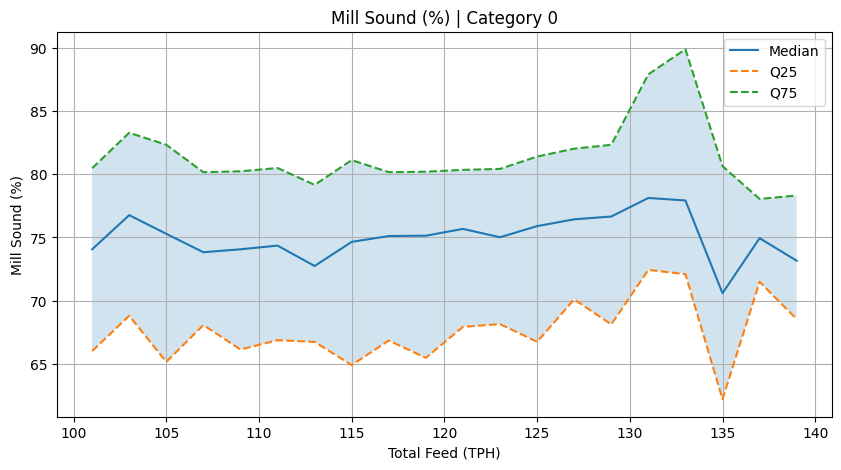

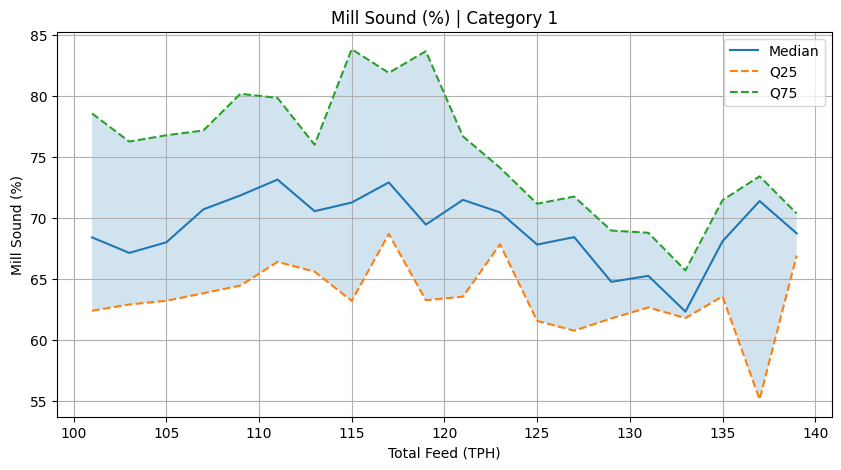

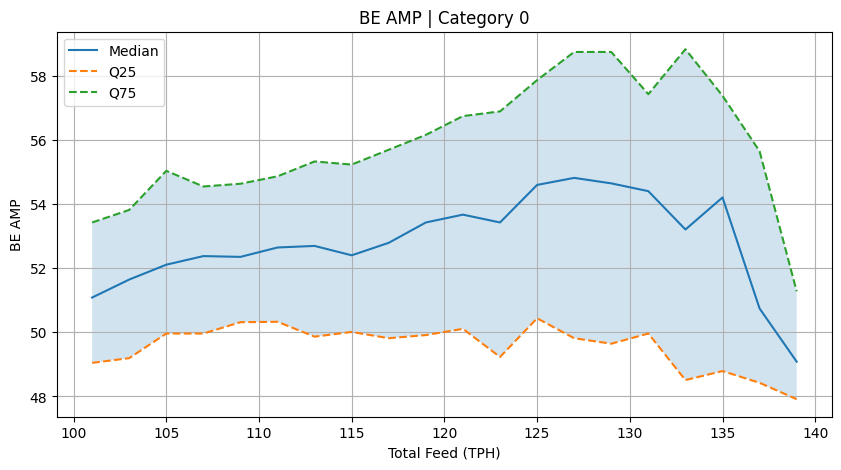

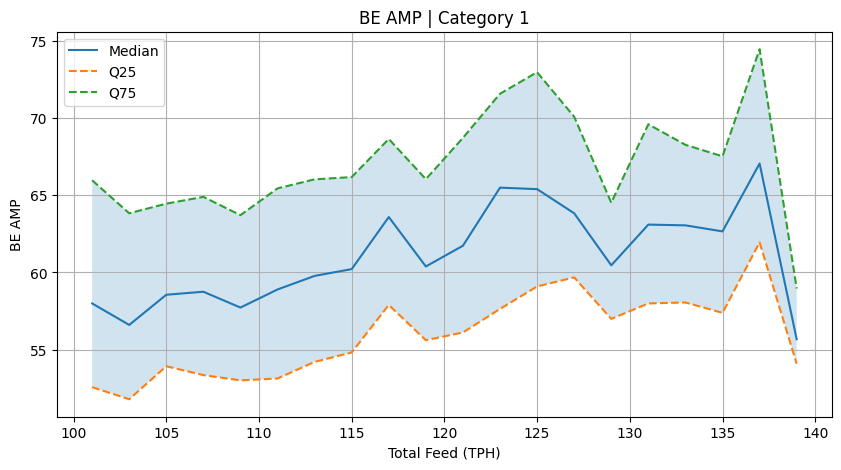

In [10]:
def plot_envelope(envelope_df, category, title):
    df_plot = envelope_df[envelope_df["cement_category"] == category].copy()

    # convert bin labels to numeric midpoint for better plotting
    df_plot["bin_mid"] = df_plot["feed_bin"].apply(
        lambda x: (int(x.split("-")[0]) + int(x.split("-")[1])) / 2
    )

    df_plot = df_plot.sort_values("bin_mid")

    plt.figure(figsize=(10, 5))

    plt.plot(df_plot["bin_mid"], df_plot["median"], label="Median")
    plt.plot(df_plot["bin_mid"], df_plot["q25"], linestyle="--", label="Q25")
    plt.plot(df_plot["bin_mid"], df_plot["q75"], linestyle="--", label="Q75")

    plt.fill_between(
        df_plot["bin_mid"],
        df_plot["q25"],
        df_plot["q75"],
        alpha=0.2
    )

    plt.title(f"{title} | Category {category}")
    plt.xlabel("Total Feed (TPH)")
    plt.ylabel(title)
    plt.legend()
    plt.grid()

    plt.show()

plot_envelope(sound_envelope, category=0, title="Mill Sound (%)")
plot_envelope(sound_envelope, category=1, title="Mill Sound (%)")
plot_envelope(amp_envelope, category=0, title="BE AMP")
plot_envelope(amp_envelope, category=1, title="BE AMP")

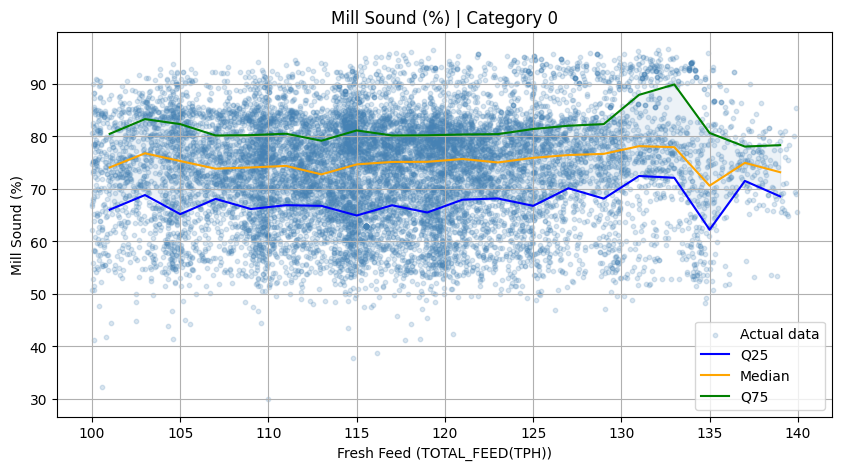

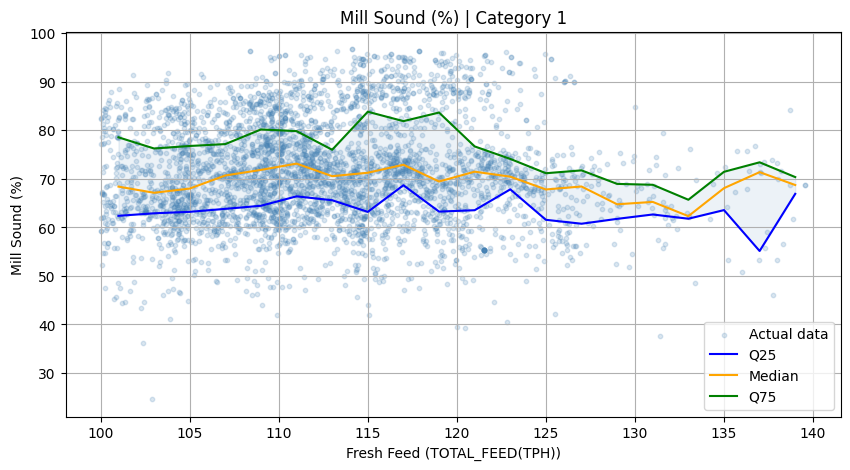

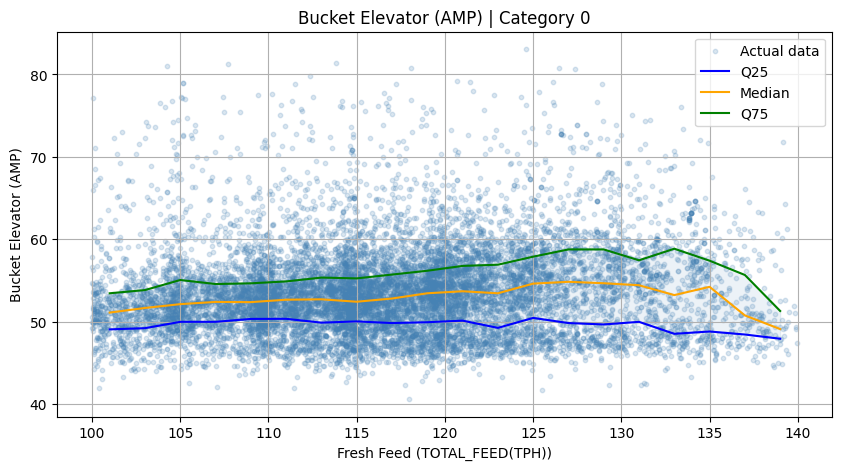

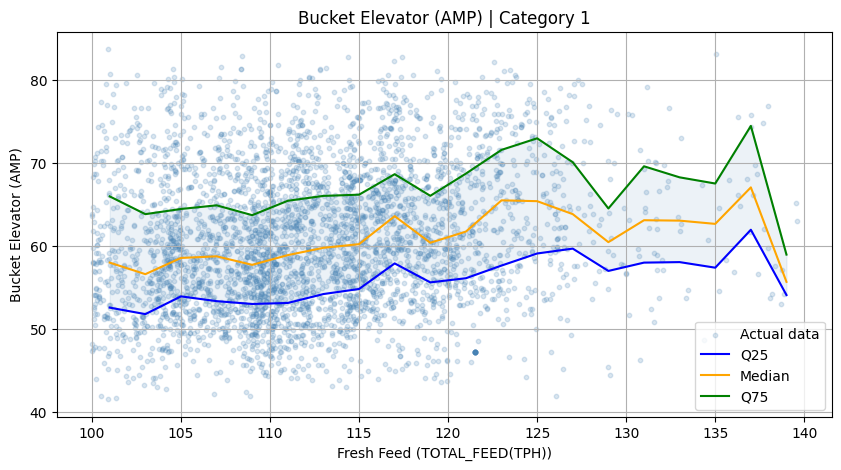

In [11]:
def plot_envelope(envelope_df, raw_df, category, title, x_col, y_col):
    df_plot = envelope_df[envelope_df["cement_category"] == category].copy()

    # Convert bin labels to numeric midpoint
    df_plot["bin_mid"] = df_plot["feed_bin"].apply(
        lambda x: (int(x.split("-")[0]) + int(x.split("-")[1])) / 2
    )
    df_plot = df_plot.sort_values("bin_mid")

    # Filter raw data for the same category
    raw_filtered = raw_df[raw_df["cement_category"] == category]

    plt.figure(figsize=(10, 5))

    # Scatter plot of actual data points (plot first so lines appear on top)
    plt.scatter(
        raw_filtered[x_col],
        raw_filtered[y_col],
        alpha=0.2,
        s=10,
        color="steelblue",
        label="Actual data"
    )

    # Envelope lines
    plt.plot(df_plot["bin_mid"], df_plot["q25"], label="Q25", color="blue")
    plt.plot(df_plot["bin_mid"], df_plot["median"], label="Median", color="orange")
    plt.plot(df_plot["bin_mid"], df_plot["q75"], label="Q75", color="green")

    plt.fill_between(
        df_plot["bin_mid"],
        df_plot["q25"],
        df_plot["q75"],
        alpha=0.1,
        color="steelblue"
    )

    plt.title(f"{title} | Category {category}")
    plt.xlabel(f"Fresh Feed ({x_col.upper()})")
    plt.ylabel(title)
    plt.legend()
    plt.grid()
    plt.show()

plot_envelope(envelope_df=sound_envelope,raw_df=df_binned,category=0,title="Mill Sound (%)",x_col="total_feed(TPH)",  y_col="mill_sound(%)")
plot_envelope(envelope_df=sound_envelope,raw_df=df_binned,category=1,title="Mill Sound (%)",x_col="total_feed(TPH)",  y_col="mill_sound(%)"    )
plot_envelope(envelope_df=amp_envelope,raw_df=df_binned,category=0,title="Bucket Elevator (AMP)",x_col="total_feed(TPH)",  y_col="bucket_elevator(AMP)")
plot_envelope(envelope_df=amp_envelope,raw_df=df_binned,category=1,title="Bucket Elevator (AMP)",x_col="total_feed(TPH)",  y_col="bucket_elevator(AMP)")

## Envelope Conclusion
####  Lower-density bins (like 134–140) → wider bands → expected
####  later we will do SME tuning via lookup table/YAML

# Convert values → STATUS (core engine)
We will:

take a single row (live data)
map it to:
sound status
& amp status

##  Now create lookup dictionaries (fast runtime access)

In [12]:
def get_status(value, q25, q75, low_label, mid_label, high_label):
    if value < q25:
        return low_label
    elif value > q75:
        return high_label
    else:
        return mid_label
    
# convert envelopes into lookup dicts

sound_lookup = sound_envelope.set_index(["cement_category", "feed_bin"]).to_dict(orient="index")

amp_lookup = amp_envelope.set_index(["cement_category", "feed_bin"]).to_dict(orient="index")

# Function to classify a single row

In [13]:
def classify_row(row):
    key = (row["cement_category"], row["feed_bin"])

    # get lookup values
    sound_ref = sound_lookup.get(key, None)
    amp_ref = amp_lookup.get(key, None)

    if sound_ref is None or amp_ref is None:
        return None, None

    # SOUND status
    sound_status = get_status(
        row["mill_sound(%)"],
        sound_ref["q25"],
        sound_ref["q75"],
        low_label="overloaded",
        mid_label="stable",
        high_label="underloaded"
    )

    # AMP status
    amp_status = get_status(
        row["bucket_elevator(AMP)"],
        amp_ref["q25"],
        amp_ref["q75"],
        low_label="low_circulation",
        mid_label="stable",
        high_label="high_circulation"
    )

    return sound_status, amp_status

In [14]:
sample = df_binned.sample(5).copy()

sample[["sound_status", "amp_status"]] = sample.apply(
    lambda row: pd.Series(classify_row(row)),
    axis=1
)

sample[[
    "cement_category",
    "total_feed(TPH)",
    "feed_bin",
    "mill_sound(%)",
    "bucket_elevator(AMP)",
    "sound_status",
    "amp_status"]]

,cement_category,total_feed(TPH),feed_bin,mill_sound(%),bucket_elevator(AMP),sound_status,amp_status
10516,0,120.585840,120-122,71.990234,58.901100,stable,high_circulation
10351,1,115.787790,114-116,73.357758,65.934067,stable,stable
6666,0,101.650061,100-102,72.893776,49.719170,stable,stable
10205,1,116.810011,116-118,71.355316,74.236877,stable,high_circulation
6834,0,106.314781,106-108,70.842491,54.749699,stable,high_circulation


# Decision Matrix → Interpretation + Action

In [15]:
decision_matrix = {
    ("underloaded", "low_circulation"): {
        "interpretation": "true_underload",
        "action": "increase",
        "severity_bias": 1
    },
    ("underloaded", "stable"): {
        "interpretation": "mild_underload",
        "action": "increase",
        "severity_bias": 0
    },
    ("underloaded", "high_circulation"): {
        "interpretation": "conflicting as mill sound suggests underload but BE amp suggest high circulation",
        "action": "increase_cautiously",
        "severity_bias": -1
    },

    ("stable", "low_circulation"): {
        "interpretation": "low_utilization",
        "action": "slight_increase",
        "severity_bias": 0
    },
    ("stable", "stable"): {
        "interpretation": "optimal",
        "action": "maintain",
        "severity_bias": 0
    },
    ("stable", "high_circulation"): {
        "interpretation": "hidden_overload",
        "action": "slight_reduce",
        "severity_bias": 0
    },

    ("overloaded", "low_circulation"): {
        "interpretation": "conflicting as mill sound suggests overload but BE amp suggest low circulation",
        "action": "small_reduce",
        "severity_bias": -1
    },
    ("overloaded", "stable"): {
        "interpretation": "overloaded",
        "action": "reduce",
        "severity_bias": 0
    },
    ("overloaded", "high_circulation"): {
        "interpretation": "severe_overload",
        "action": "reduce",
        "severity_bias": 1
    },
}


def get_decision(sound_status, amp_status):
    key = (sound_status, amp_status)
    return decision_matrix.get(key, None)

In [16]:
# sample apply
def apply_decision(row):
    decision = get_decision(row["sound_status"], row["amp_status"])

    if decision is None:
        return pd.Series([None, None, None])

    return pd.Series([
        decision["interpretation"],
        decision["action"],
        decision["severity_bias"]
    ])


sample[["interpretation", "action", "severity_bias"]] = sample.apply(
    apply_decision,
    axis=1
)

sample[["sound_status","amp_status","interpretation","action","severity_bias"]]

,sound_status,amp_status,interpretation,action,severity_bias
10516,stable,high_circulation,hidden_overload,slight_reduce,0
10351,stable,stable,optimal,maintain,0
6666,stable,stable,optimal,maintain,0
10205,stable,high_circulation,hidden_overload,slight_reduce,0
6834,stable,high_circulation,hidden_overload,slight_reduce,0


# Convert into actual TPH recommendation

In [17]:
def compute_severity(row, sound_ref):
    """
    Calculate how far the value is outside the stable band
    """

    value = row["mill_sound(%)"]
    q25 = sound_ref["q25"]
    q75 = sound_ref["q75"]

    band_width = max(q75 - q25, 0.1)  # avoid divide by zero

    if value < q25:
        deviation = (q25 - value) / band_width
    elif value > q75:
        deviation = (value - q75) / band_width
    else:
        return 0  # stable

    return deviation

# Map deviation → base severity
def map_severity_level(deviation):
    if deviation < 0.5:
        return 1   # mild
    elif deviation < 1.0:
        return 2   # moderate
    else:
        return 3   # severe

# Final recommendation function

In [18]:
def get_feed_recommendation(row):
    key = (row["cement_category"], row["feed_bin"])

    sound_ref = sound_lookup.get(key, None)
    if sound_ref is None:
        return None

    decision = get_decision(row["sound_status"], row["amp_status"])
    if decision is None:
        return None

    action = decision["action"]
    bias = decision["severity_bias"]

    # if stable → no change
    if action == "maintain":
        return 0

    # compute base severity
    deviation = compute_severity(row, sound_ref)
    base_level = map_severity_level(deviation)

    # apply bias
    final_level = max(1, min(3, base_level + bias))

    # convert to signed TPH change
    if "increase" in action:
        return +final_level
    elif "reduce" in action:
        return -final_level
    else:
        return 0

In [19]:
sample["tph_change"] = sample.apply(get_feed_recommendation, axis=1)

sample[[
    "sound_status",
    "amp_status",
    "interpretation",
    "severity_bias",
    "action",
    "tph_change"]]

,sound_status,amp_status,interpretation,severity_bias,action,tph_change
10516,stable,high_circulation,hidden_overload,0,slight_reduce,-1
10351,stable,stable,optimal,0,maintain,0
6666,stable,stable,optimal,0,maintain,0
10205,stable,high_circulation,hidden_overload,0,slight_reduce,-1
6834,stable,high_circulation,hidden_overload,0,slight_reduce,-1


In [20]:
row = sample.iloc[0]
key = (row["cement_category"], row["feed_bin"])
sound_ref = sound_lookup[key]

print("Sound:", row["mill_sound(%)"])
print("Q25:", sound_ref["q25"])
print("Deviation:", compute_severity(row, sound_ref))

Sound: 71.99023438
Q25: 67.93650818
Deviation: 0


# Create final client-facing output text

In [21]:
def build_feed_advisory(row):
    sound_status = row["sound_status"]
    amp_status = row["amp_status"]
    interpretation = row["interpretation"]
    tph_change = row["tph_change"]

    # recommendation text
    if tph_change > 0:
        recommendation = f"Increase feed by {tph_change} TPH"
    elif tph_change < 0:
        recommendation = f"Reduce feed by {abs(tph_change)} TPH"
    else:
        recommendation = "Maintain current feed"

    # reason text
    reason = (
        f"Mill sound is '{sound_status}' and bucket elevator condition is '{amp_status}' "
        f"for the current feed bin {row['feed_bin']}."
    )

    # caution text only for conflicting cases
    caution = ""
    if interpretation == "conflicting" or "conflicting" in str(interpretation).lower():
        caution = "Check circulation/separator condition before making a large feed correction."

    return pd.Series([interpretation, recommendation, reason, caution])

In [22]:
sample[["final_interpretation", "recommendation_text", "reason_text", "caution_text"]] = sample.apply(
    build_feed_advisory,
    axis=1)

sample[[
    "cement_category",
    "total_feed(TPH)",
    "feed_bin",
    "mill_sound(%)",
    "bucket_elevator(AMP)",
    "final_interpretation",
    "recommendation_text",
    "reason_text",
    "caution_text"]]

,cement_category,total_feed(TPH),feed_bin,mill_sound(%),bucket_elevator(AMP),final_interpretation,recommendation_text,reason_text,caution_text
10516,0,120.585840,120-122,71.990234,58.901100,hidden_overload,Reduce feed by 1 TPH,Mill sound is 'stable' and bucket elevator con...,
10351,1,115.787790,114-116,73.357758,65.934067,optimal,Maintain current feed,Mill sound is 'stable' and bucket elevator con...,
6666,0,101.650061,100-102,72.893776,49.719170,optimal,Maintain current feed,Mill sound is 'stable' and bucket elevator con...,
10205,1,116.810011,116-118,71.355316,74.236877,hidden_overload,Reduce feed by 1 TPH,Mill sound is 'stable' and bucket elevator con...,
6834,0,106.314781,106-108,70.842491,54.749699,hidden_overload,Reduce feed by 1 TPH,Mill sound is 'stable' and bucket elevator con...,


In [23]:
df_model = df_binned.copy()

df_model[["sound_status", "amp_status"]] = df_model.apply(
    lambda row: pd.Series(classify_row(row)),
    axis=1
)

df_model[["interpretation", "action", "severity_bias"]] = df_model.apply(
    apply_decision,
    axis=1
)

df_model["tph_change"] = df_model.apply(get_feed_recommendation, axis=1)

df_model[["final_interpretation", "recommendation_text", "reason_text", "caution_text"]] = df_model.apply(
    build_feed_advisory,
    axis=1
)

df_model

,Datetime,total_feed(TPH),reject(TPH),sep_drive_speed(RPM),bucket_elevator(AMP),mill_sound(%),cement_category,feed_bin,sound_status,amp_status,interpretation,action,severity_bias,tph_change,final_interpretation,recommendation_text,reason_text,caution_text
0,2023-04-01 00:00:00,118.486454,8.024420,570.733521,53.821735,78.437119,0,118-120,stable,stable,optimal,maintain,0,0,optimal,Maintain current feed,Mill sound is 'stable' and bucket elevator con...,
1,2023-04-01 01:00:00,119.675951,14.042735,570.733521,58.315022,81.343102,0,118-120,underloaded,high_circulation,conflicting as mill sound suggests underload b...,increase_cautiously,-1,1,conflicting as mill sound suggests underload b...,Increase feed by 1 TPH,Mill sound is 'underloaded' and bucket elevato...,Check circulation/separator condition before m...
2,2023-04-01 02:00:00,119.404398,16.890110,570.733521,58.119659,83.418808,0,118-120,underloaded,high_circulation,conflicting as mill sound suggests underload b...,increase_cautiously,-1,1,conflicting as mill sound suggests underload b...,Increase feed by 1 TPH,Mill sound is 'underloaded' and bucket elevato...,Check circulation/separator condition before m...
3,2023-04-01 03:00:00,118.955072,8.024420,570.733521,58.998783,84.053726,0,118-120,underloaded,high_circulation,conflicting as mill sound suggests underload b...,increase_cautiously,-1,1,conflicting as mill sound suggests underload b...,Increase feed by 1 TPH,Mill sound is 'underloaded' and bucket elevato...,Check circulation/separator condition before m...
4,2023-04-01 04:00:00,119.241518,13.978023,570.733521,58.608063,82.881561,0,118-120,underloaded,high_circulation,conflicting as mill sound suggests underload b...,increase_cautiously,-1,1,conflicting as mill sound suggests underload b...,Increase feed by 1 TPH,Mill sound is 'underloaded' and bucket elevato...,Check circulation/separator condition before m...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16422,2026-01-30 18:00:00,108.732602,142.627609,826.604187,58.754581,90.695969,1,108-110,underloaded,stable,mild_underload,increase,0,2,mild_underload,Increase feed by 2 TPH,Mill sound is 'underloaded' and bucket elevato...,
16423,2026-01-30 19:00:00,110.864469,264.094025,808.479981,62.222225,89.841270,1,110-112,underloaded,stable,mild_underload,increase,0,2,mild_underload,Increase feed by 2 TPH,Mill sound is 'underloaded' and bucket elevato...,
16424,2026-01-30 21:00:00,104.230777,79.661789,834.067078,52.356537,89.719170,0,104-106,underloaded,stable,mild_underload,increase,0,1,mild_underload,Increase feed by 1 TPH,Mill sound is 'underloaded' and bucket elevato...,
16425,2026-01-30 22:00:00,104.261301,215.429794,900.166992,55.286938,84.737488,0,104-106,underloaded,high_circulation,conflicting as mill sound suggests underload b...,increase_cautiously,-1,1,conflicting as mill sound suggests underload b...,Increase feed by 1 TPH,Mill sound is 'underloaded' and bucket elevato...,Check circulation/separator condition before m...


In [24]:
print(df_model["recommendation_text"].value_counts().head(10))
print()
print(df_model["final_interpretation"].value_counts())

recommendation_text
Reduce feed by 1 TPH      4585
Increase feed by 1 TPH    4583
Maintain current feed     3730
Increase feed by 2 TPH    1441
Reduce feed by 2 TPH      1350
Reduce feed by 3 TPH       426
Increase feed by 3 TPH     244
Name: count, dtype: int64

final_interpretation
optimal                                                                             3730
overloaded                                                                          2587
hidden_overload                                                                     2275
low_utilization                                                                     2182
mild_underload                                                                      1905
true_underload                                                                      1101
conflicting as mill sound suggests underload but BE amp suggest high circulation    1080
conflicting as mill sound suggests overload but BE amp suggest low circulation       793
sev

# Build final user input → output function

In [25]:
def assign_feed_bin(total_tph, start=100, end=140, step=2):
    if total_tph < start or total_tph >= end:
        return None

    bin_start = start + int((total_tph - start) // step) * step
    bin_end = bin_start + step
    return f"{int(bin_start)}-{int(bin_end)}"

In [26]:
def get_feed_advisory_input(cement_category, total_tph, mill_sound, be_amp):
    # basic validation
    if cement_category not in [0, 1]:
        return {
            "error": "Invalid cement_category. Allowed values are 0 and 1."
        }

    if total_tph <= 0 or mill_sound <= 0 or be_amp <= 0:
        return {
            "error": "Inputs must be greater than 0."
        }

    # assign bin
    feed_bin = assign_feed_bin(total_tph, start=100, end=140, step=2)

    if feed_bin is None:
        return {
            "error": "TOTALTPH is outside configured feed bin range (100 to 140)."
        }

    # build temporary row
    row = {
        "cement_category": cement_category,
        "total_feed(TPH)": total_tph,
        "mill_sound(%)": mill_sound,
        "bucket_elevator(AMP)": be_amp,
        "feed_bin": feed_bin
    }
    row = pd.Series(row)

    # classify
    sound_status, amp_status = classify_row(row)

    if sound_status is None or amp_status is None:
        return {
            "error": "Lookup not found for given category and feed bin."
        }

    row["sound_status"] = sound_status
    row["amp_status"] = amp_status

    # decision
    decision = get_decision(sound_status, amp_status)
    if decision is None:
        return {
            "error": "Decision matrix mapping not found."
        }

    row["interpretation"] = decision["interpretation"]
    row["action"] = decision["action"]
    row["severity_bias"] = decision["severity_bias"]

    # tph recommendation
    tph_change = get_feed_recommendation(row)
    row["tph_change"] = tph_change

    # advisory text
    final_interpretation, recommendation_text, reason_text, caution_text = build_feed_advisory(row)

    return {
        "cement_category": cement_category,
        "total_feed(TPH)": total_tph,
        "feed_bin": feed_bin,
        "mill_sound(%)": mill_sound,
        "bucket_elevator(AMP)": be_amp,
        "sound_status": sound_status,
        "amp_status": amp_status,
        "interpretation": final_interpretation,
        "recommendation": recommendation_text,
        "reason": reason_text,
        "caution": caution_text
    }

In [27]:
test_1 = get_feed_advisory_input(
    cement_category=0,
    total_tph=120,
    mill_sound=60,
    be_amp=58
)

test_2 = get_feed_advisory_input(
    cement_category=0,
    total_tph=120,
    mill_sound=90,
    be_amp=50
)

test_3 = get_feed_advisory_input(
    cement_category=1,
    total_tph=118,
    mill_sound=65,
    be_amp=67
)

for i, test in enumerate([test_1, test_2, test_3], start=1):
    print(f"\n--- Test {i} ---")
    for k, v in test.items():
        print(f"{k}: {v}")


--- Test 1 ---
cement_category: 0
total_feed(TPH): 120
feed_bin: 120-122
mill_sound(%): 60
bucket_elevator(AMP): 58
sound_status: overloaded
amp_status: high_circulation
interpretation: severe_overload
recommendation: Reduce feed by 3 TPH
reason: Mill sound is 'overloaded' and bucket elevator condition is 'high_circulation' for the current feed bin 120-122.
caution: 

--- Test 2 ---
cement_category: 0
total_feed(TPH): 120
feed_bin: 120-122
mill_sound(%): 90
bucket_elevator(AMP): 50
sound_status: underloaded
amp_status: low_circulation
interpretation: true_underload
recommendation: Increase feed by 3 TPH
reason: Mill sound is 'underloaded' and bucket elevator condition is 'low_circulation' for the current feed bin 120-122.
caution: 

--- Test 3 ---
cement_category: 1
total_feed(TPH): 118
feed_bin: 118-120
mill_sound(%): 65
bucket_elevator(AMP): 67
sound_status: stable
amp_status: high_circulation
interpretation: hidden_overload
recommendation: Reduce feed by 1 TPH
reason: Mill sound is

# Build the separator RPM advisory from fineness target

We will use:

### category 0 = PPC → target Blaine = 395
### category 1 = OPC → target Blaine = 295

And:

% RPM change = % Blaine gap. (
correction factor = 0 for now)

In [28]:
def get_separator_advisory(cement_category, current_blaine, current_sep_rpm, correction_factor_pct=0):
    # validate inputs
    if cement_category not in [0, 1]:
        return {
            "error": "Invalid cement_category. Allowed values are 0 and 1."
        }

    if current_blaine <= 0 or current_sep_rpm <= 0:
        return {
            "error": "Blaine and separator RPM must be greater than 0."
        }

    # category target
    if cement_category == 0:
        product_name = "PPC"
        target_blaine = 395
    else:
        product_name = "OPC"
        target_blaine = 295

    # percent change needed in blaine
    blaine_gap_pct = ((target_blaine - current_blaine) / current_blaine) * 100

    # separator rpm change %
    rpm_change_pct = blaine_gap_pct + correction_factor_pct

    # new separator rpm
    suggested_sep_rpm = current_sep_rpm * (1 + rpm_change_pct / 100)

    # interpretation
    if blaine_gap_pct > 0:
        interpretation = "Blaine below target"
        recommendation = f"Increase separator RPM by {abs(rpm_change_pct):.2f}%"
    elif blaine_gap_pct < 0:
        interpretation = "Blaine above target"
        recommendation = f"Reduce separator RPM by {abs(rpm_change_pct):.2f}%"
    else:
        interpretation = "Blaine on target"
        recommendation = "Maintain current separator RPM"

    reason = (
        f"{product_name} target Blaine is {target_blaine}. "
        f"Current Blaine is {current_blaine}, so required Blaine correction is {blaine_gap_pct:.2f}%."
    )

    return {
        "cement_category": cement_category,
        "product_name": product_name,
        "current_blaine": current_blaine,
        "target_blaine": target_blaine,
        "blaine_gap_pct": round(blaine_gap_pct, 2),
        "current_sep_rpm": current_sep_rpm,
        "recommended_sep_rpm_change_pct": round(rpm_change_pct, 2),
        "suggested_sep_rpm": round(suggested_sep_rpm, 2),
        "interpretation": interpretation,
        "recommendation": recommendation,
        "reason": reason
    }

In [29]:
sep_test_1 = get_separator_advisory(
    cement_category=0,
    current_blaine=360,
    current_sep_rpm=700
)

sep_test_2 = get_separator_advisory(
    cement_category=0,
    current_blaine=405,
    current_sep_rpm=700
)

sep_test_3 = get_separator_advisory(
    cement_category=1,
    current_blaine=280,
    current_sep_rpm=650
)

for i, test in enumerate([sep_test_1, sep_test_2, sep_test_3], start=1):
    print(f"\n--- Separator Test {i} ---")
    for k, v in test.items():
        print(f"{k}: {v}")


--- Separator Test 1 ---
cement_category: 0
product_name: PPC
current_blaine: 360
target_blaine: 395
blaine_gap_pct: 9.72
current_sep_rpm: 700
recommended_sep_rpm_change_pct: 9.72
suggested_sep_rpm: 768.06
interpretation: Blaine below target
recommendation: Increase separator RPM by 9.72%
reason: PPC target Blaine is 395. Current Blaine is 360, so required Blaine correction is 9.72%.

--- Separator Test 2 ---
cement_category: 0
product_name: PPC
current_blaine: 405
target_blaine: 395
blaine_gap_pct: -2.47
current_sep_rpm: 700
recommended_sep_rpm_change_pct: -2.47
suggested_sep_rpm: 682.72
interpretation: Blaine above target
recommendation: Reduce separator RPM by 2.47%
reason: PPC target Blaine is 395. Current Blaine is 405, so required Blaine correction is -2.47%.

--- Separator Test 3 ---
cement_category: 1
product_name: OPC
current_blaine: 280
target_blaine: 295
blaine_gap_pct: 5.36
current_sep_rpm: 650
recommended_sep_rpm_change_pct: 5.36
suggested_sep_rpm: 684.82
interpretation: 

# Create a combined demo-ready interface ---------------------------

The easiest notebook demo is to create two wrapper functions:

#### process/feed advisory
#### quality/separator advisory

And then show clean printed output.

In [30]:
def print_advisory(result_dict, title="Advisory Output"):
    print(f"\n{'='*60}")
    print(title)
    print(f"{'='*60}")

    if "error" in result_dict:
        print("Error:", result_dict["error"])
        return

    for k, v in result_dict.items():
        print(f"{k}: {v}")


# feed wrapper
def run_feed_demo(cement_category, total_tph, mill_sound, be_amp):
    result = get_feed_advisory_input(
        cement_category=cement_category,
        total_tph=total_tph,
        mill_sound=mill_sound,
        be_amp=be_amp
    )
    print_advisory(result, title="Feed Advisory")
    return result

# separator wrapper
def run_separator_demo(cement_category, current_blaine, current_sep_rpm):
    result = get_separator_advisory(
        cement_category=cement_category,
        current_blaine=current_blaine,
        current_sep_rpm=current_sep_rpm
    )
    print_advisory(result, title="Separator Advisory")
    return result

In [31]:
feed_demo = run_feed_demo(
    cement_category=0,
    total_tph=120,
    mill_sound=60,
    be_amp=65)

sep_demo = run_separator_demo(
    cement_category=0,
    current_blaine=360,
    current_sep_rpm=700)


Feed Advisory
cement_category: 0
total_feed(TPH): 120
feed_bin: 120-122
mill_sound(%): 60
bucket_elevator(AMP): 65
sound_status: overloaded
amp_status: high_circulation
interpretation: severe_overload
recommendation: Reduce feed by 3 TPH
reason: Mill sound is 'overloaded' and bucket elevator condition is 'high_circulation' for the current feed bin 120-122.
caution: 

Separator Advisory
cement_category: 0
product_name: PPC
current_blaine: 360
target_blaine: 395
blaine_gap_pct: 9.72
current_sep_rpm: 700
recommended_sep_rpm_change_pct: 9.72
suggested_sep_rpm: 768.06
interpretation: Blaine below target
recommendation: Increase separator RPM by 9.72%
reason: PPC target Blaine is 395. Current Blaine is 360, so required Blaine correction is 9.72%.


In [32]:
def get_feed_advisory_client_view(cement_category, total_tph, mill_sound, be_amp):
    result = get_feed_advisory_input(cement_category, total_tph, mill_sound, be_amp)

    if "error" in result:
        return result

    return {
        "Input Cement Category": result["cement_category"],
        "Input Total Feed (TPH)": result["total_feed(TPH)"],
        "Input Mill Sound (%)": result["mill_sound(%)"],
        "Input Bucket Elevator AMP": result["bucket_elevator(AMP)"],
        "Feed Bin": result["feed_bin"],
        "Interpretation": result["interpretation"],
        "Recommendation": result["recommendation"],
        "Reason": result["reason"],
        "Caution": result["caution"]
    }

def get_separator_advisory_client_view(cement_category, current_blaine, current_sep_rpm):
    result = get_separator_advisory(cement_category, current_blaine, current_sep_rpm)

    if "error" in result:
        return result

    return {
        "Input Cement Category": result["cement_category"],
        "Input Current Blaine": result["current_blaine"],
        "Input Current Separator RPM": result["current_sep_rpm"],
        "Target Blaine": result["target_blaine"],
        "Interpretation": result["interpretation"],
        "Recommendation": result["recommendation"],
        "Suggested Separator RPM": result["suggested_sep_rpm"],
        "Reason": result["reason"]
    }

In [33]:
client_feed = get_feed_advisory_client_view(
    cement_category=0,
    total_tph=120,
    mill_sound=60,
    be_amp=65
)

client_sep = get_separator_advisory_client_view(
    cement_category=0,
    current_blaine=350,
    current_sep_rpm=700
)

print_advisory(client_feed, title="Client View - Feed Advisory")
print_advisory(client_sep, title="Client View - Separator Advisory")


Client View - Feed Advisory
Input Cement Category: 0
Input Total Feed (TPH): 120
Input Mill Sound (%): 60
Input Bucket Elevator AMP: 65
Feed Bin: 120-122
Interpretation: severe_overload
Recommendation: Reduce feed by 3 TPH
Reason: Mill sound is 'overloaded' and bucket elevator condition is 'high_circulation' for the current feed bin 120-122.
Caution: 

Client View - Separator Advisory
Input Cement Category: 0
Input Current Blaine: 350
Input Current Separator RPM: 700
Target Blaine: 395
Interpretation: Blaine below target
Recommendation: Increase separator RPM by 12.86%
Suggested Separator RPM: 790.0
Reason: PPC target Blaine is 395. Current Blaine is 350, so required Blaine correction is 12.86%.


# save the lookup tables

In [34]:
sound_envelope.to_csv("sound_envelope.csv", index=False)
amp_envelope.to_csv("amp_envelope.csv", index=False)